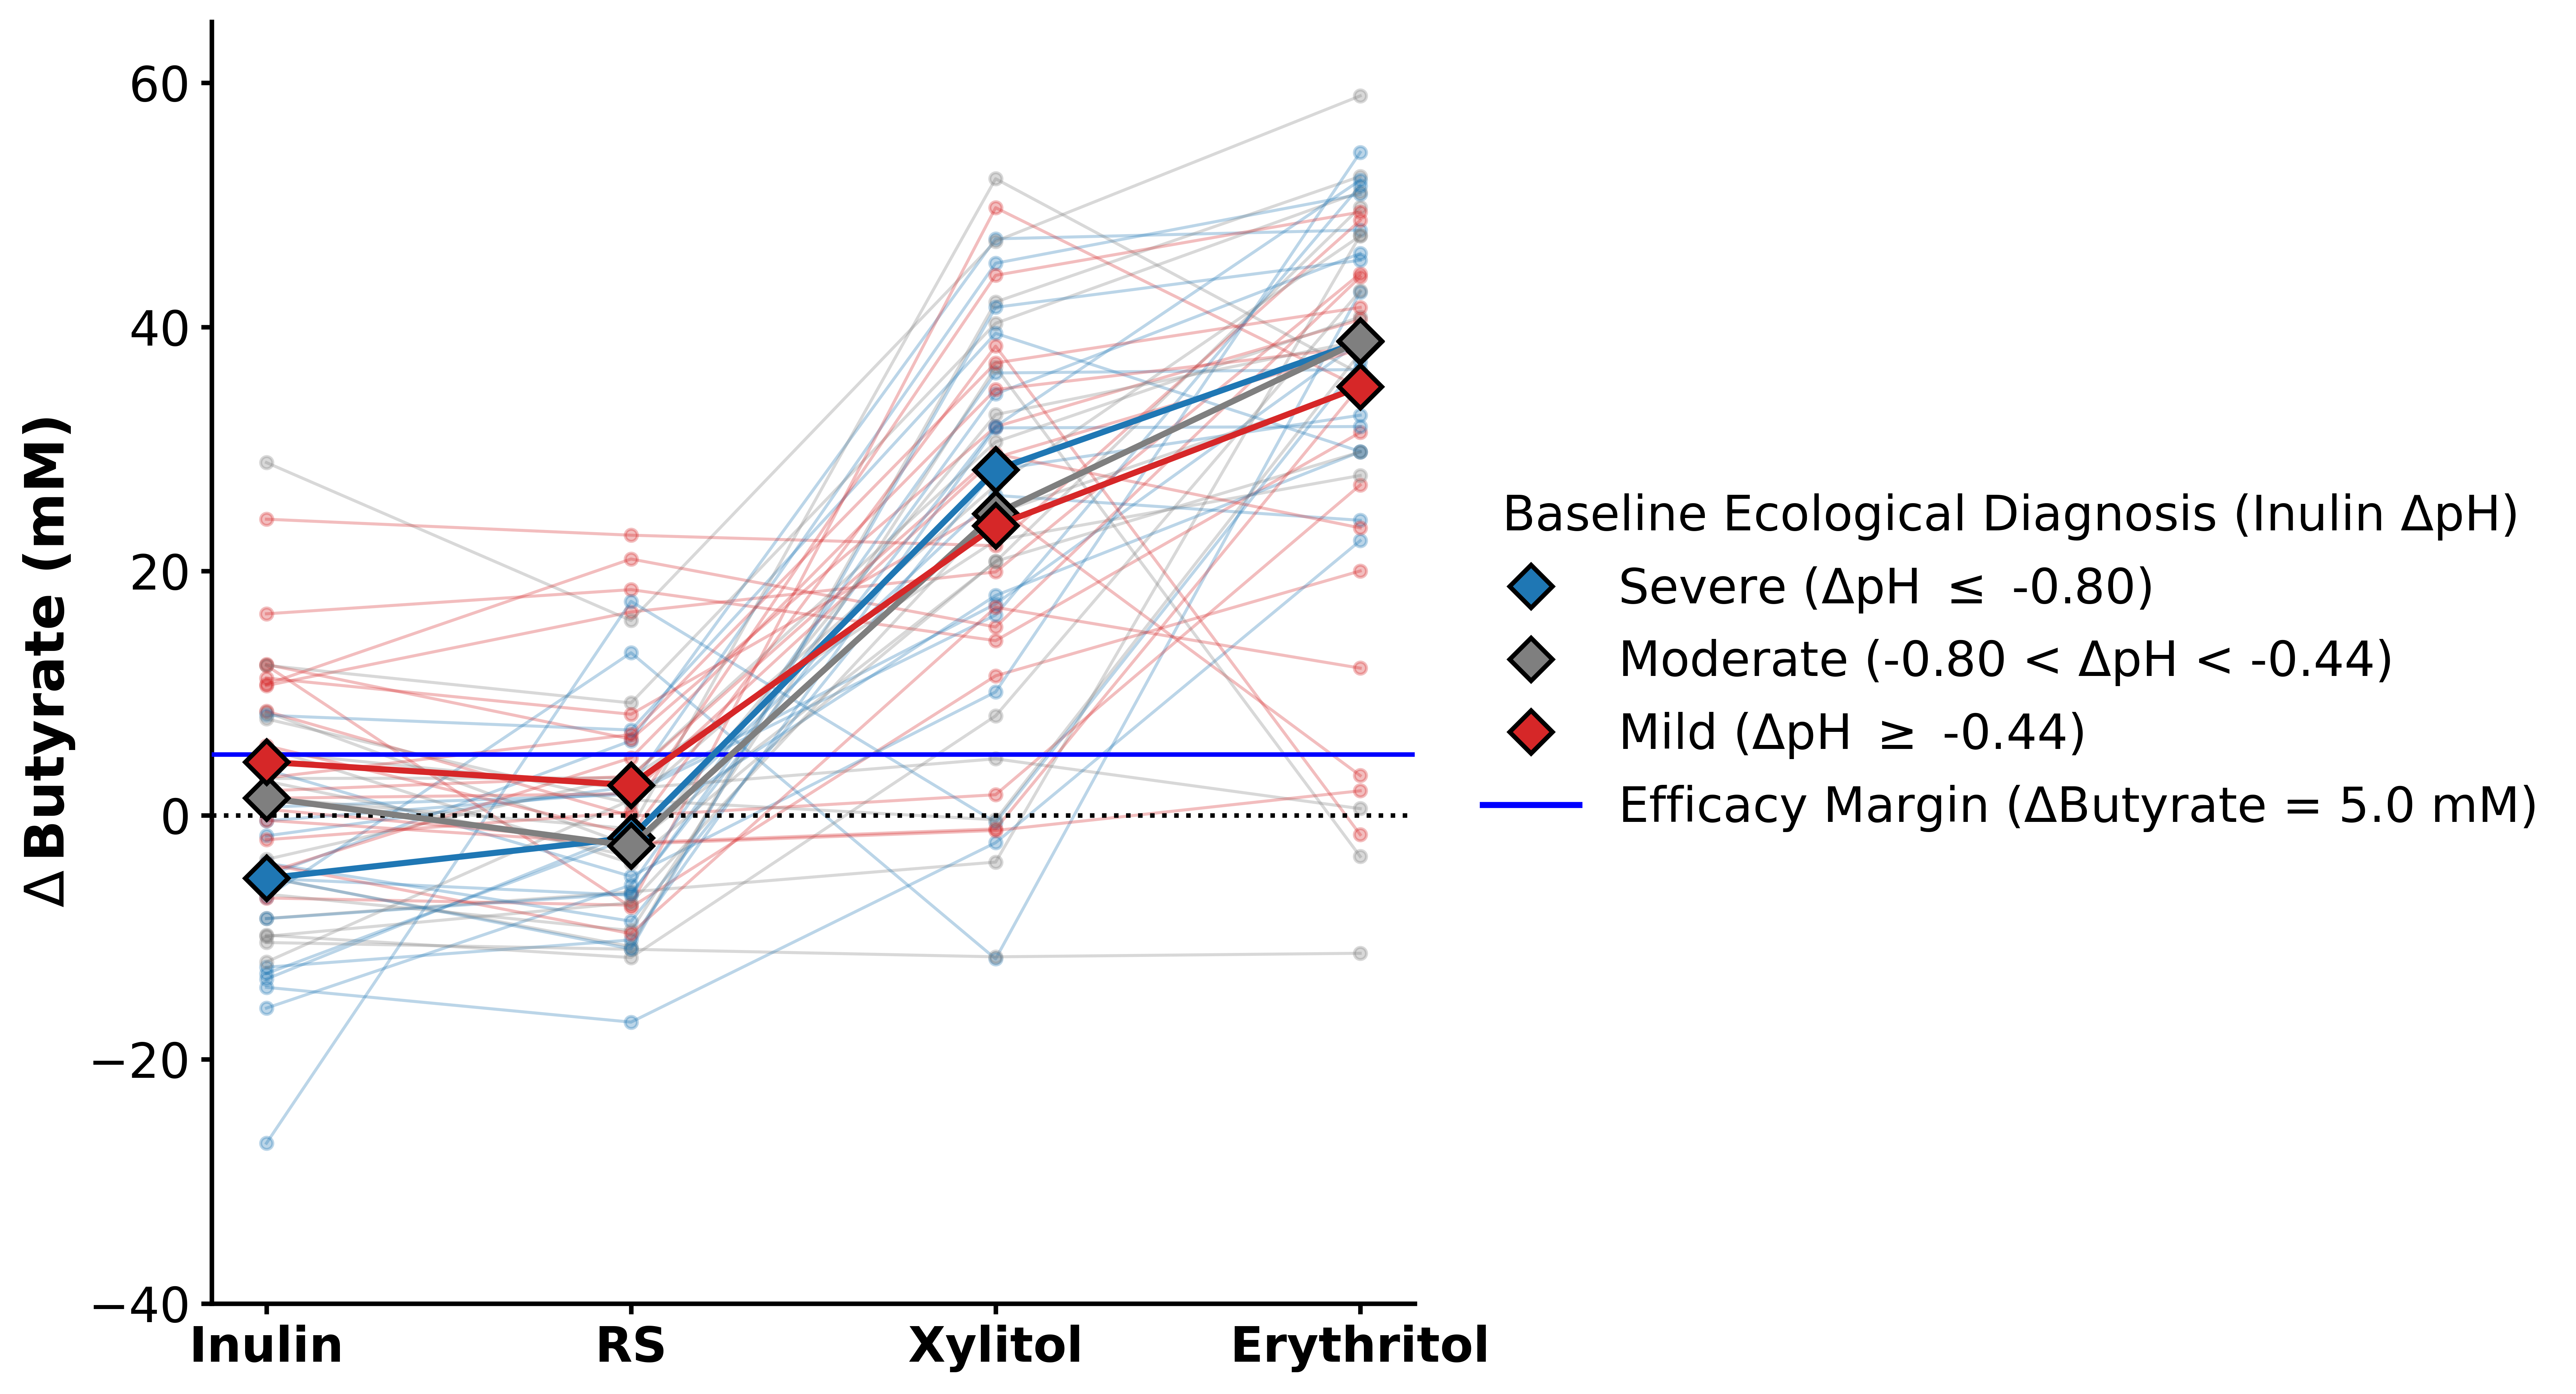

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

DPI_SETTING = 600
EFFICACY_THRESHOLD = 5.0

df_ph = pd.read_csv('pH.csv')
df_buty = pd.read_csv('Butyrate(mM).csv')
donors = [c for c in df_ph.columns if c.startswith('HS-')]

def get_data(df, name):
    mask = df['KULFFI'].str.strip() == name
    if not mask.any(): return pd.Series(index=donors, dtype=float)
    s = df[mask][donors].iloc[0]
    s = s.astype(str).replace(['Undetermined', '-', 'nan', '#VALUE!', ''], np.nan)
    return pd.to_numeric(s, errors='coerce')

ctrl_ph = get_data(df_ph, 'Control')
ctrl_buty = get_data(df_buty, 'Control')

inulin_ph = get_data(df_ph, 'Inulin') - ctrl_ph

subs = ['Inulin', 'Resistant starch', 'Xylitol', 'Erythritol']
labels = ['Inulin', 'RS', 'Xylitol', 'Erythritol']

df_buty_delta = pd.DataFrame()
for s, l in zip(subs, labels):
    df_buty_delta[l] = get_data(df_buty, s) - ctrl_buty

valid_donors = df_buty_delta.dropna().index.intersection(inulin_ph.dropna().index)
df_buty_delta = df_buty_delta.loc[valid_donors]
inulin_ph = inulin_ph.loc[valid_donors]

def classify_ecotype(val):
    if val <= -0.80: return 'Severe'
    elif val < -0.44: return 'Moderate'
    else: return 'Mild'

df_buty_delta['Ecotype'] = inulin_ph.apply(classify_ecotype)
df_buty_delta['Donor'] = df_buty_delta.index

df_melt = df_buty_delta.melt(id_vars=['Donor', 'Ecotype'], value_vars=labels,
                             var_name='Substrate', value_name='Delta_Butyrate')

palette = {'Mild': '#d62728', 'Moderate': '#7f7f7f', 'Severe': '#1f77b4'}

fig, ax = plt.subplots(figsize=(12, 6.5), dpi=DPI_SETTING)

for d in valid_donors:
    d_data = df_melt[df_melt['Donor'] == d].copy()
    d_data['Substrate'] = pd.Categorical(d_data['Substrate'], categories=labels, ordered=True)
    d_data = d_data.sort_values('Substrate')
    eco = d_data['Ecotype'].iloc[0]
    ax.plot(d_data['Substrate'], d_data['Delta_Butyrate'], color=palette[eco],
            alpha=0.3, linewidth=1.0, marker='o', markersize=4, zorder=1)

medians = df_melt.groupby(['Ecotype', 'Substrate'])['Delta_Butyrate'].median().reset_index()

for eco in ['Severe', 'Moderate', 'Mild']:
    m_data = medians[medians['Ecotype'] == eco].copy()
    m_data['Substrate'] = pd.Categorical(m_data['Substrate'], categories=labels, ordered=True)
    m_data = m_data.sort_values('Substrate')
    ax.plot(m_data['Substrate'], m_data['Delta_Butyrate'], marker='D', markersize=10,
            linewidth=2.0, alpha=1.0, color=palette[eco], markeredgecolor='black',
            markeredgewidth=1.5, zorder=5)

ax.axhline(EFFICACY_THRESHOLD, color='blue', linestyle='-', linewidth=1.5, zorder=4)
ax.axhline(0, color='black', linestyle=':', linewidth=1.5, zorder=4)

ax.set_ylabel(r'$\Delta\,$Butyrate (mM)', fontsize=18, fontweight='bold')
ax.set_xlabel('')

ax.set_ylim(-40, 65)
ax.tick_params(axis='both', labelsize=16)
ax.set_xticklabels(labels, fontweight='bold', fontsize=16)

legend_elements = [
    mlines.Line2D([0], [0], marker='D', color='w', markerfacecolor='#1f77b4', markersize=10, markeredgecolor='black', markeredgewidth=1.5, linewidth=2.0, label=r'Severe ($\Delta$pH $\leq$ -0.80)'),
    mlines.Line2D([0], [0], marker='D', color='w', markerfacecolor='#7f7f7f', markersize=10, markeredgecolor='black', markeredgewidth=1.5, linewidth=2.0, label=r'Moderate (-0.80 < $\Delta$pH < -0.44)'),
    mlines.Line2D([0], [0], marker='D', color='w', markerfacecolor='#d62728', markersize=10, markeredgecolor='black', markeredgewidth=1.5, linewidth=2.0, label=r'Mild ($\Delta$pH $\geq$ -0.44)'),
    mlines.Line2D([0], [0], color='blue', linewidth=2, linestyle='-', label=r'Efficacy Margin ($\Delta$Butyrate = 5.0 mM)')
]

ax.legend(handles=legend_elements, title=r'Baseline Ecological Diagnosis (Inulin $\Delta$pH)',
          loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1, frameon=False, fontsize=16, title_fontsize=16)

sns.despine(trim=False)
plt.tight_layout()
output_file = 'Figure_7a.pdf'
plt.savefig(output_file, dpi=DPI_SETTING, bbox_inches='tight')